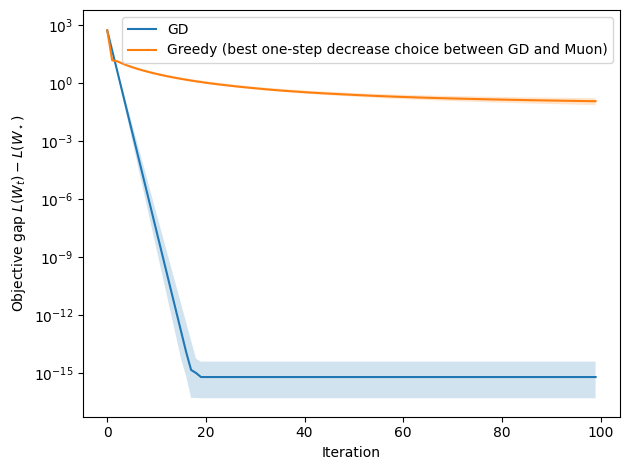

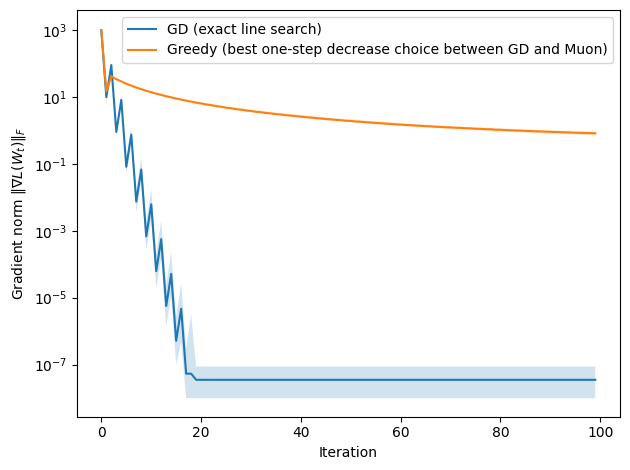

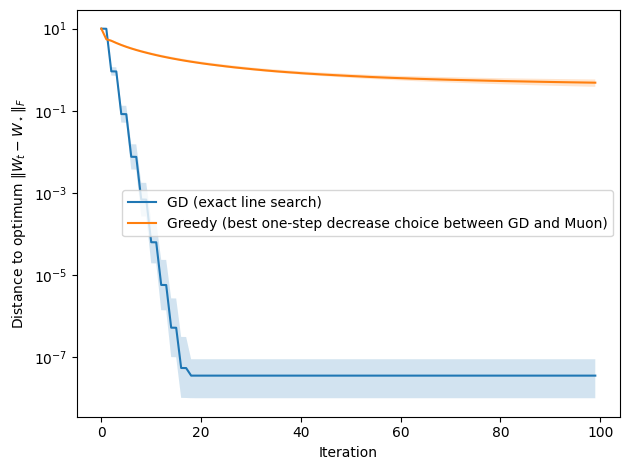

In [ ]:
"""
Figure 5 (Section 5) and Figure 16 (Appendix G): quadratic exact line search.

We minimize
    L(W) = 0.5 <W, A W> - <B, W>   with A SPD
using:
  - GD: exact line search along D = grad
  - Greedy: at each step, choose between D = grad and D = polar(grad)
            whichever yields larger exact line search decrease.

This script reproduces:
  - Figure 5: objective gap vs iteration (median + central 95% over seeds)
  - Figure 16: grad norm and distance to optimum (same aggregation)
"""

import os
import numpy as np
import matplotlib.pyplot as plt


# Quadratic instance generation: A = Q diag(1,...,1,kappa) Q^T for random orthogonal Q

def make_rotated_spd(n: int, kappa: float, seed: int) -> np.ndarray:
    rng = np.random.default_rng(seed)
    M = rng.standard_normal((n, n))
    Q, R = np.linalg.qr(M)
    s = np.sign(np.diag(R))
    s[s == 0] = 1.0
    Q = Q * s # for uniform sampling of orthogonal matrices: Q ~ QR with R's diag positive = Uniform(O(n))
    eig = np.ones(n)
    eig[-1] = float(kappa)
    return Q @ np.diag(eig) @ Q.T


# Loss, gradient, line search, polar projection

def loss(W: np.ndarray, A: np.ndarray, B: np.ndarray) -> float:
    # 0.5 <W, A W> - <B, W>
    return 0.5 * float(np.sum(W * (A @ W))) - float(np.sum(B * W))

def grad(W: np.ndarray, A: np.ndarray, B: np.ndarray) -> np.ndarray:
    return A @ W - B

def exact_ls_alpha_and_decrease(G: np.ndarray, A: np.ndarray, D: np.ndarray, eps: float = 1e-14):
    """
    For L(W - alpha D) with quadratic and gradient G at W, returns:
      alpha* = <D,G> / <D, A D>, the step size minimizing L(W - alpha D) in alpha
      decrease = (<D,G>^2) / (2 <D, A D>), the corresponding decrease in L at this alpha*, compared to L(W)
    """
    num = float(np.sum(D * G))
    den = float(np.sum(D * (A @ D)))
    if den <= eps:
        return 0.0, 0.0
    alpha = num / den
    dec = (num * num) / (2.0 * den)
    return alpha, dec

def polar(G: np.ndarray) -> np.ndarray:
    """Orthogonal polar factor of the gradient G: argmin_{U orthogonal} ||G-U||_F."""
    U, _, Vt = np.linalg.svd(G, full_matrices=False)
    return U @ Vt

# One run (one seed)

def run_one(
    A: np.ndarray,
    B: np.ndarray,
    W_star: np.ndarray,
    L_star: float,
    seed_init: int,
    steps: int,
):
    rng = np.random.default_rng(seed_init)
    n = A.shape[0]

    # Init: (W0)_{ij} ~ N(0, 1/n)
    W0 = rng.normal(loc=0.0, scale=1.0 / np.sqrt(n), size=(n, n))

    W_gd = W0.copy() # GD trajectory
    W_gr = W0.copy() # Greedy trajectory (choose best between GD and polar at each step)

    gap_gd = np.empty(steps) # gap L(W_t) - L(W_star) at each step
    gap_gr = np.empty(steps)
    gnorm_gd = np.empty(steps) # gradient norm at each step
    gnorm_gr = np.empty(steps)
    dist_gd = np.empty(steps) # distance to optimum ||W_t - W_star||_F at each step
    dist_gr = np.empty(steps)

    for t in range(steps):
        # ---- GD ----
        G = grad(W_gd, A, B)
        gap_gd[t] = loss(W_gd, A, B) - L_star
        gnorm_gd[t] = np.linalg.norm(G, ord="fro")
        dist_gd[t] = np.linalg.norm(W_gd - W_star, ord="fro")

        alpha, _ = exact_ls_alpha_and_decrease(G, A, D=G)
        W_gd = W_gd - alpha * G

        # ---- Greedy (best between GD direction and polar direction) ----
        G = grad(W_gr, A, B)
        gap_gr[t] = loss(W_gr, A, B) - L_star
        gnorm_gr[t] = np.linalg.norm(G, ord="fro")
        dist_gr[t] = np.linalg.norm(W_gr - W_star, ord="fro")

        D_gd = G
        D_mu = polar(G)

        alpha_gd, dec_gd = exact_ls_alpha_and_decrease(G, A, D=D_gd)
        alpha_mu, dec_mu = exact_ls_alpha_and_decrease(G, A, D=D_mu)

        if dec_mu > dec_gd:
            W_gr = W_gr - alpha_mu * D_mu
        else:
            W_gr = W_gr - alpha_gd * D_gd

    return {
        "gap_gd": gap_gd,
        "gap_gr": gap_gr,
        "gnorm_gd": gnorm_gd,
        "gnorm_gr": gnorm_gr,
        "dist_gd": dist_gd,
        "dist_gr": dist_gr,
    }



# Aggregation over seeds (different inits W_0) + plotting utilities

def quantile_band(X: np.ndarray, q_lo=2.5, q_mid=50.0, q_hi=97.5):
    mid = np.percentile(X, q_mid, axis=0)
    lo = np.percentile(X, q_lo, axis=0)
    hi = np.percentile(X, q_hi, axis=0)
    return mid, lo, hi

def plot_with_band(y_mid, y_lo, y_hi, label):
    x = np.arange(len(y_mid))
    plt.plot(x, y_mid, label=label)
    plt.fill_between(x, y_lo, y_hi, alpha=0.2)

def savefig(path_prefix: str):
    plt.tight_layout()
    plt.savefig(path_prefix + ".pdf")


# ----------------------------
# Main
# ----------------------------

if __name__ == "__main__":
    n = 100 # n x n matrices W, A, B
    kappa = 1e3 # A = Q diag(1,...,1,kappa) Q^T
    steps = 100 # iterations of GD and Greedy
    nb_seeds = 100 # number of different initializations W_0 to average over for the plots
    seed_quad = 128 # seed for generating the quadratic instance (A, B)

    A = make_rotated_spd(n, kappa=kappa, seed=seed_quad)
    B = np.zeros((n, n), dtype=float)  # = 0, but keep general if wanted to test nonzero B
    W_star = np.linalg.solve(A, B)     # = 0, but keep general
    L_star = loss(W_star, A, B)

    runs = []
    for seed_init in range(nb_seeds):
        runs.append(run_one(A=A, B=B, W_star=W_star, L_star=L_star, seed_init=seed_init, steps=steps))

    # Stack arrays: shape (nb_seeds, steps)
    gap_gd = np.stack([r["gap_gd"] for r in runs], axis=0)
    gap_gr = np.stack([r["gap_gr"] for r in runs], axis=0)
    gnorm_gd = np.stack([r["gnorm_gd"] for r in runs], axis=0)
    gnorm_gr = np.stack([r["gnorm_gr"] for r in runs], axis=0)
    dist_gd = np.stack([r["dist_gd"] for r in runs], axis=0)
    dist_gr = np.stack([r["dist_gr"] for r in runs], axis=0)

    out_dir = "./images"
    os.makedirs(out_dir, exist_ok=True)
    prefix = os.path.join(out_dir, f"fig5_quad_n{n}_kappa{kappa:g}_seeds{nb_seeds}_steps{steps}")

    # --- Figure 5: objective gap ---
    plt.figure()
    gd_mid, gd_lo, gd_hi = quantile_band(gap_gd)
    gr_mid, gr_lo, gr_hi = quantile_band(gap_gr)
    plot_with_band(gd_mid, gd_lo, gd_hi, "GD")
    plot_with_band(gr_mid, gr_lo, gr_hi, "Greedy (best one-step decrease choice between GD and Muon)")
    plt.yscale("log")
    plt.xlabel("Iteration")
    plt.ylabel(r"Objective gap $L(W_t)-L(W_\star)$")
    plt.legend()
    savefig(prefix + "_gap")
    plt.show()

    # --- Figure 16 (left): gradient norm ---
    plt.figure()
    gd_mid, gd_lo, gd_hi = quantile_band(gnorm_gd)
    gr_mid, gr_lo, gr_hi = quantile_band(gnorm_gr)
    plot_with_band(gd_mid, gd_lo, gd_hi, "GD (exact line search)")
    plot_with_band(gr_mid, gr_lo, gr_hi, "Greedy (best one-step decrease choice between GD and Muon)")
    plt.yscale("log")
    plt.xlabel("Iteration")
    plt.ylabel(r"Gradient norm $\|\nabla L(W_t)\|_F$")
    plt.legend()
    savefig(prefix + "_gnorm")
    plt.show()

    # --- Figure 16 (right): distance to optimum ---
    plt.figure()
    gd_mid, gd_lo, gd_hi = quantile_band(dist_gd)
    gr_mid, gr_lo, gr_hi = quantile_band(dist_gr)
    plot_with_band(gd_mid, gd_lo, gd_hi, "GD (exact line search)")
    plot_with_band(gr_mid, gr_lo, gr_hi, "Greedy (best one-step decrease choice between GD and Muon)")
    plt.yscale("log")
    plt.xlabel("Iteration")
    plt.ylabel(r"Distance to optimum $\|W_t - W_\star\|_F$")
    plt.legend()
    savefig(prefix + "_dist")
    plt.show()